In [22]:
import pandas as pd

df = pd.read_csv("data/classification_data.csv")
print(df.head())

                  category                                          embedding
0  Artificial Intelligence  [-0.053605832159519196, 0.048988278955221176, ...
1  Artificial Intelligence  [0.05853476747870445, -0.013236680068075657, -...
2  Artificial Intelligence  [0.10836952179670334, -0.07507780939340591, -0...
3  Artificial Intelligence  [-0.024970736354589462, -0.055218443274497986,...
4  Artificial Intelligence  [-0.05750409513711929, -0.09207653254270554, -...


<Axes: xlabel='category'>

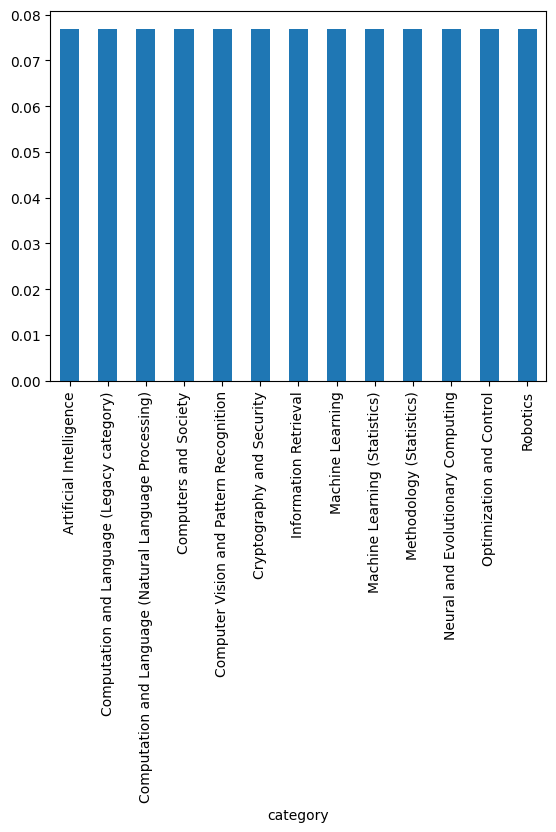

In [27]:
import numpy as np
import ast

df['embedding'] = df['embedding'].apply(lambda x: np.array(ast.literal_eval(x)))
df['category'].value_counts(normalize=True).plot.bar()

In [31]:
X = np.vstack(df['embedding'].values)
y = df['category'].values

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print('Training Data: ', X_train.shape)
print('Test Data: ', X_test.shape)

Training Data:  (5200, 384)
Test Data:  (1300, 384)


In [32]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [34]:
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7361538461538462


In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=le.classes_))

                                                        precision    recall  f1-score   support

                               Artificial Intelligence       0.56      0.55      0.55       100
            Computation and Language (Legacy category)       0.87      0.82      0.85       100
Computation and Language (Natural Language Processing)       0.69      0.72      0.70       100
               Computer Vision and Pattern Recognition       0.80      0.86      0.83       100
                                 Computers and Society       0.76      0.73      0.74       100
                             Cryptography and Security       0.89      0.93      0.91       100
                                 Information Retrieval       0.81      0.76      0.78       100
                                      Machine Learning       0.54      0.43      0.48       100
                         Machine Learning (Statistics)       0.51      0.37      0.43       100
                              Methodolo

In [43]:
import os
import pickle

artifacts = {
    "model": model,
    "label_encoder": le
}

models_dir = os.path.join(os.getcwd(), "models")
os.makedirs(models_dir, exist_ok=True)

output_path = os.path.join(models_dir, "classification_artifacts.pkl")

with open(output_path, "wb") as f:
    pickle.dump(artifacts, f)

print(f"Artifacts saved to {output_path}")

Artifacts saved to /home/pradooguilherme/Documents/Projetos/ai-research-assistant/ai-service/ml/classification/models/classification_artifacts.pkl
